---
**标题:** 序列并行 (Sequence Parallelism, SP)

**类别:** 序列并行

**难度:** 中级

**预计时间:** 40 分钟

---

## 概述

**张量并行 (Tensor Parallelism, TP)** 将权重矩阵拆分到多个 GPU 上——但 LayerNorm 和 Dropout 呢？这些操作仍然在每个 GPU 上保留**完整的激活值**，浪费显存。

**序列并行 (Sequence Parallelism, SP)** 通过在这些非 TP 区域沿**序列维度**拆分，将激活显存按 GPU 数量等比减少。

本 notebook 逐步讲解：

1. 为什么仅用 TP 会浪费激活显存
2. **归约散射 (ReduceScatter)** 集合通信——AllGather 的逆操作
3. SP 区域：将 LayerNorm 和 Dropout 拆分到多个 GPU
4. SP 与 TP 在 Transformer 层中如何耦合
5. 量化显存节省

### 前置知识
- [02-tensor-parallelism/](02-tensor-parallelism.ipynb) — 列并行 (Column-Parallel)、行并行 (Row-Parallel)、共轭对、AllReduce
- LayerNorm 和 Dropout 的基本概念

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

from mp_tutorial.viz import show_matrix, show_matrices_row, GPU_COLORS
from mp_tutorial.distributed import (
    simulate_allreduce, simulate_allgather, simulate_reduce_scatter, check_gpu_env
)
from mp_tutorial.formatting import code_reference

check_gpu_env()
torch.manual_seed(42)

%matplotlib inline

✗ No CUDA GPU detected on this machine.

To run GPU-required cells, use a machine with CUDA GPUs (4+ recommended).
See README.md for remote Jupyter setup instructions.


---
## 1. 问题：TP 浪费激活显存

回顾 TP notebook：在 Transformer 层中，MLP 和自注意力 (Self-Attention) 通过 TP 并行——每个 GPU 只持有权重矩阵的一个**切片**。

但 Transformer 层还有 **LayerNorm** 和 **Dropout**。这些操作作用于完整的隐藏维度，不涉及权重拆分。仅用 TP 时，每个 GPU 都保留这些操作的**完整激活副本**。

**激活显存 (Activation Memory)** 是前向传播中存储中间结果所用的显存——反向传播时需要这些中间结果。对于大模型和长序列，激活显存可能占据 GPU 显存的大部分。

来看看每个 GPU 存储了什么：

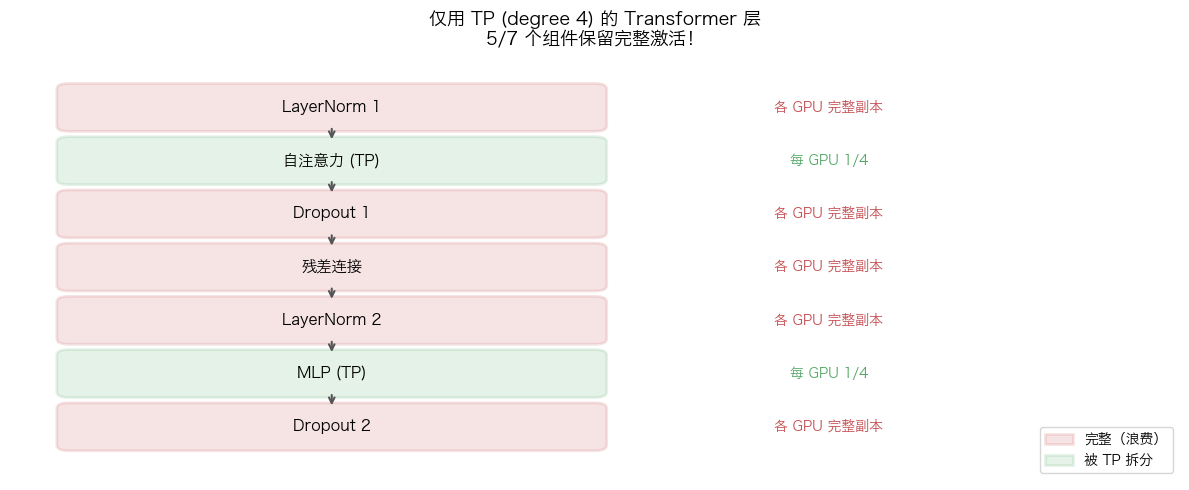

7 个组件中 5 个保留完整激活副本——大量显存被浪费！


In [2]:
def draw_tp_activation_waste(num_gpus=4):
    """展示仅用 TP 时哪些激活被重复存储 vs 被拆分。"""
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis("off")

    # Transformer 层的各组件
    components = [
        (7.0, "LayerNorm 1",            f"各 GPU 完整副本",     "#C44E52"),
        (6.0, "自注意力 (TP)",           f"每 GPU 1/{num_gpus}", "#55A868"),
        (5.0, "Dropout 1",              f"各 GPU 完整副本",     "#C44E52"),
        (4.0, "残差连接",                f"各 GPU 完整副本",     "#C44E52"),
        (3.0, "LayerNorm 2",            f"各 GPU 完整副本",     "#C44E52"),
        (2.0, "MLP (TP)",               f"每 GPU 1/{num_gpus}", "#55A868"),
        (1.0, "Dropout 2",              f"各 GPU 完整副本",     "#C44E52"),
    ]

    num_full = sum(1 for _, _, s, _ in components if "完整" in s)
    num_split = sum(1 for _, _, s, _ in components if "1/" in s)

    for y, label, status, color in components:
        box = mpatches.FancyBboxPatch(
            (0.5, y - 0.35), 4.5, 0.7,
            boxstyle="round,pad=0.1", facecolor=color, alpha=0.15,
            edgecolor=color, linewidth=2
        )
        ax.add_patch(box)
        ax.text(2.75, y, label, ha="center", va="center",
                fontsize=11, fontweight="bold")
        ax.text(7, y, status, ha="center", va="center",
                fontsize=10, color=color, fontweight="bold")

    for i in range(len(components) - 1):
        y1 = components[i][0] - 0.35
        y2 = components[i + 1][0] + 0.35
        ax.annotate("", xy=(2.75, y2), xytext=(2.75, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"))

    ax.set_title(
        f"仅用 TP (degree {num_gpus}) 的 Transformer 层\n"
        f"{num_full}/{num_full + num_split} 个组件保留完整激活！",
        fontsize=13, fontweight="bold"
    )

    full_patch = mpatches.Patch(facecolor="#C44E52", alpha=0.15, edgecolor="#C44E52",
                                linewidth=2, label="完整（浪费）")
    split_patch = mpatches.Patch(facecolor="#55A868", alpha=0.15, edgecolor="#55A868",
                                 linewidth=2, label="被 TP 拆分")
    ax.legend(handles=[full_patch, split_patch], loc="lower right", fontsize=10)

    fig.tight_layout()
    return fig

fig = draw_tp_activation_waste()
plt.show()

print("7 个组件中 5 个保留完整激活副本——大量显存被浪费！")

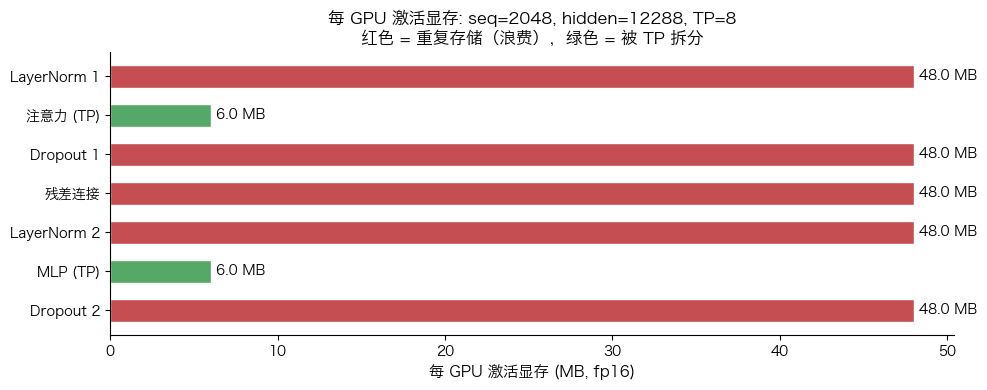

重复存储的激活: 240.0 MB / GPU
被 TP 拆分的:   12.0 MB / GPU
比例: 95% 的激活显存是重复浪费的！


In [3]:
# 具体显存示例：GPT-3 规模的层
seq_len = 2048
hidden = 12288
num_gpus = 8
bytes_per_elem = 2  # fp16

# 各组件的激活形状: (seq_len, hidden) 每样本
act_size = seq_len * hidden * bytes_per_elem  # 每个激活张量的字节数

components = {
    "LayerNorm 1":  act_size,
    "注意力 (TP)": act_size // num_gpus,  # 已拆分
    "Dropout 1":    act_size,
    "残差连接":     act_size,
    "LayerNorm 2":  act_size,
    "MLP (TP)":     act_size // num_gpus,  # 已拆分
    "Dropout 2":    act_size,
}

# 柱状图可视化
fig, ax = plt.subplots(figsize=(10, 4))
names = list(components.keys())
sizes_mb = [v / 1024**2 for v in components.values()]
colors = ["#C44E52" if "TP" not in n else "#55A868" for n in names]

bars = ax.barh(names, sizes_mb, color=colors, edgecolor="white", height=0.6)
for bar, val in zip(bars, sizes_mb):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} MB", va="center", fontsize=10, fontweight="bold")

ax.set_xlabel("每 GPU 激活显存 (MB, fp16)", fontsize=11)
ax.set_title(f"每 GPU 激活显存: seq={seq_len}, hidden={hidden}, TP={num_gpus}\n"
             f"红色 = 重复存储（浪费），绿色 = 被 TP 拆分",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

full_total = sum(v for n, v in components.items() if "TP" not in n) / 1024**2
split_total = sum(v for n, v in components.items() if "TP" in n) / 1024**2
print(f"重复存储的激活: {full_total:.1f} MB / GPU")
print(f"被 TP 拆分的:   {split_total:.1f} MB / GPU")
print(f"比例: {full_total / (full_total + split_total):.0%} 的激活显存是重复浪费的！")

**核心思路：** LayerNorm 和 Dropout 对每个 token **独立操作**（激活张量的每一行），因此可以沿**序列维度**拆分——让每个 GPU 处理不同的 token 子集。这就是**序列并行 (Sequence Parallelism)**。

---
## 2. 归约散射 (ReduceScatter)：缺失的一环

要让 SP 工作，我们需要一个新的集合通信操作：**归约散射 (ReduceScatter)**。

回顾 TP notebook：
- **AllReduce** = 对所有 GPU 的张量求和，每个 GPU 得到完整结果
- **AllGather** = 拼接所有 GPU 的张量，每个 GPU 得到完整结果

**ReduceScatter** 是 AllGather 的逆操作：
1. **归约 (Reduce)** — 对所有 GPU 的张量逐元素求和（类似 AllReduce）
2. **散射 (Scatter)** — 将结果拆分为若干块，GPU *i* 得到第 *i* 块

关键洞察：**AllReduce = ReduceScatter + AllGather**（总通信量相同，但 ReduceScatter 后每个 GPU 只持有 1/N 的结果）。

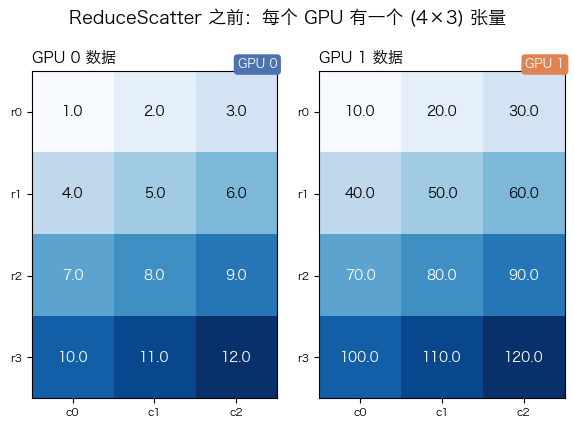

In [4]:
# 用小张量观察 ReduceScatter
# 2 个 GPU，每个有一个 (4, 3) 张量
torch.manual_seed(7)
gpu0_data = torch.tensor([[1., 2., 3.],
                           [4., 5., 6.],
                           [7., 8., 9.],
                           [10., 11., 12.]])

gpu1_data = torch.tensor([[10., 20., 30.],
                           [40., 50., 60.],
                           [70., 80., 90.],
                           [100., 110., 120.]])

fig = show_matrices_row(
    [gpu0_data, gpu1_data],
    titles=["GPU 0 数据", "GPU 1 数据"],
    gpu_labels=["GPU 0", "GPU 1"],
    suptitle="ReduceScatter 之前：每个 GPU 有一个 (4×3) 张量",
    cmap="Blues"
)
plt.show()

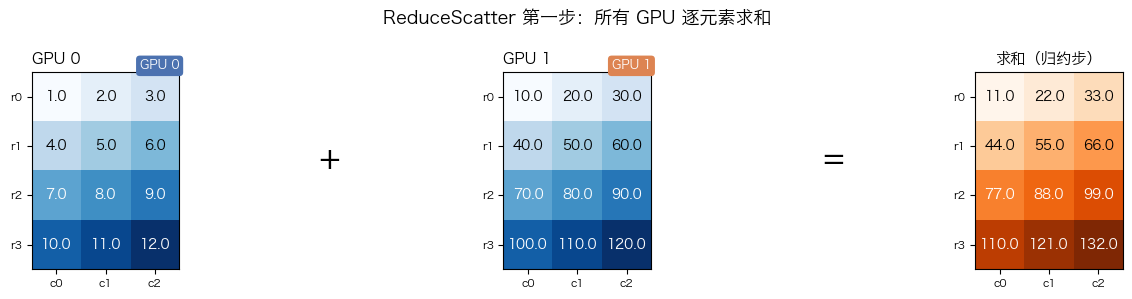

In [5]:
# 第一步：归约（求和） → 第二步：散射（拆分）
reduced_sum = gpu0_data + gpu1_data  # 逐元素求和

fig, axes = plt.subplots(1, 3, figsize=(16, 3))
show_matrix(gpu0_data, ax=axes[0], title="GPU 0", gpu_label="GPU 0", cmap="Blues")
show_matrix(gpu1_data, ax=axes[1], title="GPU 1", gpu_label="GPU 1", cmap="Blues")
show_matrix(reduced_sum, ax=axes[2], title="求和（归约步）", cmap="Oranges")
fig.text(0.345, 0.45, "+", fontsize=24, fontweight="bold", ha="center")
fig.text(0.66, 0.45, "=", fontsize=24, fontweight="bold", ha="center")
fig.suptitle("ReduceScatter 第一步：所有 GPU 逐元素求和",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

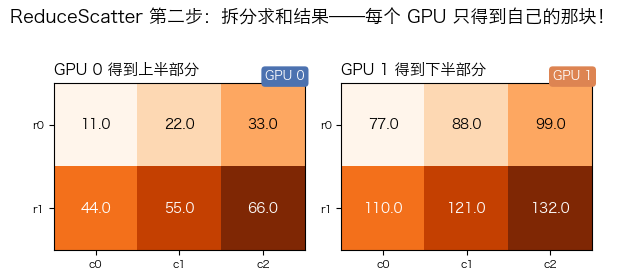

之前：每个 GPU 的形状 torch.Size([4, 3])
之后：每个 GPU 的形状 torch.Size([2, 3]) —— 显存减半！

ReduceScatter = 归约（求和）+ 散射（沿 dim 0 拆分）


In [6]:
# 第二步：散射——拆分求和结果，GPU i 得到第 i 块
results = simulate_reduce_scatter([gpu0_data, gpu1_data])

fig = show_matrices_row(
    results,
    titles=["GPU 0 得到上半部分", "GPU 1 得到下半部分"],
    gpu_labels=["GPU 0", "GPU 1"],
    suptitle="ReduceScatter 第二步：拆分求和结果——每个 GPU 只得到自己的那块！",
    cmap="Oranges"
)
plt.show()

print(f"之前：每个 GPU 的形状 {gpu0_data.shape}")
print(f"之后：每个 GPU 的形状 {results[0].shape} —— 显存减半！")
print()
print("ReduceScatter = 归约（求和）+ 散射（沿 dim 0 拆分）")

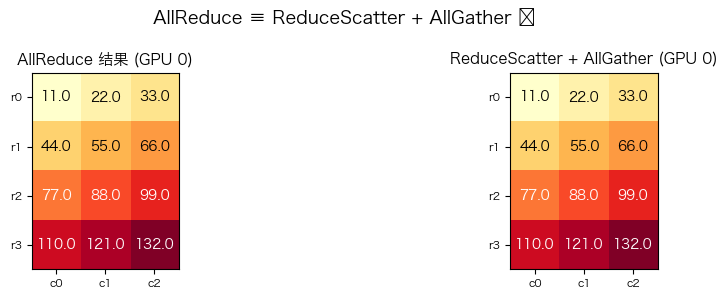

✓ 结果相同！但 ReduceScatter 之后每个 GPU 只持有 1/N 的数据。


In [7]:
# 验证 AllReduce = ReduceScatter + AllGather
# 首先直接 AllReduce：
allreduced = simulate_allreduce([gpu0_data, gpu1_data])

# 然后 ReduceScatter 再 AllGather：
scattered = simulate_reduce_scatter([gpu0_data, gpu1_data])
gathered = simulate_allgather(scattered)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
show_matrix(allreduced[0], ax=axes[0], title="AllReduce 结果 (GPU 0)")
show_matrix(gathered[0],   ax=axes[1], title="ReduceScatter + AllGather (GPU 0)")
fig.suptitle("AllReduce ≡ ReduceScatter + AllGather ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(allreduced[0], gathered[0])
print("✓ 结果相同！但 ReduceScatter 之后每个 GPU 只持有 1/N 的数据。")

### 通信量对比

| 操作 | 各 GPU 初始持有 | 各 GPU 最终持有 | 通信量 |
|------|----------------|----------------|--------|
| **AllReduce** | (S, H) | **(S, H)** — 完整 | 2×S×H / GPU |
| **ReduceScatter** | (S, H) | **(S/N, H)** — 分块 | S×H / GPU |
| **AllGather** | (S/N, H) | **(S, H)** — 完整 | S×H / GPU |
| **ReduceScatter + AllGather** | (S, H) | **(S, H)** — 完整 | 2×S×H / GPU |

总通信量相同，但 ReduceScatter 让我们在 SP 区域**保持分区状态**！

---
## 3. SP 区域：拆分 LayerNorm 和 Dropout

LayerNorm 和 Dropout 都对每个 token **独立操作**（即激活张量 `(seq_len, hidden)` 的每一行）。因此可以安全地沿序列维度拆分——每个 GPU 处理一部分 token。

**LayerNorm** 将每个 token 的隐藏向量归一化为零均值、单位方差。由于各 token 独立归一化，按序列拆分是安全的。

**Dropout** 在训练时随机将部分元素置零。同样，它逐元素独立作用，所以按序列拆分是安全的。

用一个小例子来演示：

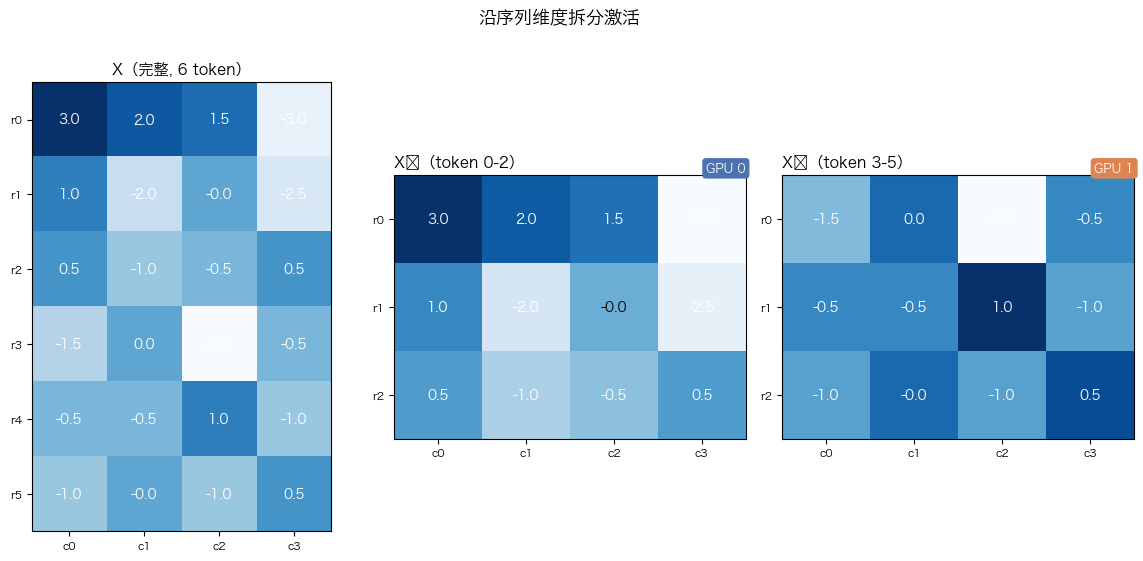

In [8]:
# 完整激活: 6 个 token, hidden=4, 2 个 GPU
torch.manual_seed(42)
seq_len, hidden_dim, num_gpus = 6, 4, 2
X = (torch.randn(seq_len, hidden_dim) * 3).round() / 2

layer_norm = nn.LayerNorm(hidden_dim)

# 参考: 单 GPU 上的 LayerNorm
Y_ref = layer_norm(X)

# SP: 拆分序列，独立做 LayerNorm，检查结果
X_chunks = X.chunk(num_gpus, dim=0)  # 沿序列维度拆分

fig = show_matrices_row(
    [X] + list(X_chunks),
    titles=["X（完整, 6 token）", "X₀（token 0-2）", "X₁（token 3-5）"],
    gpu_labels=[None, "GPU 0", "GPU 1"],
    suptitle="沿序列维度拆分激活",
    cmap="Blues"
)
plt.show()

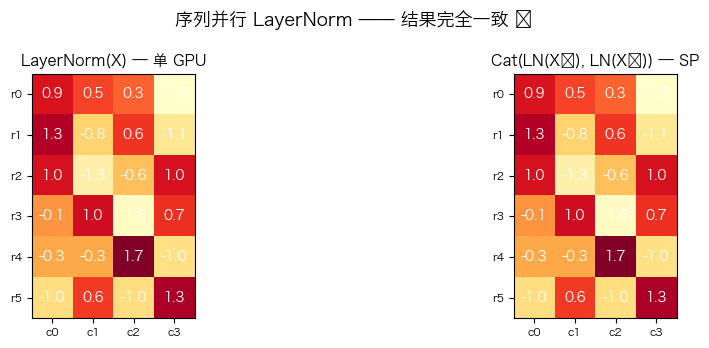

✓ SP LayerNorm 结果匹配！每个 GPU 独立处理自己的 token。


In [9]:
# 每个 GPU 对自己的分块做 LayerNorm —— 无需通信！
Y_chunks = [layer_norm(chunk) for chunk in X_chunks]
Y_sp = torch.cat(Y_chunks, dim=0)  # 拼接以便比较

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
show_matrix(Y_ref, ax=axes[0], title="LayerNorm(X) — 单 GPU")
show_matrix(Y_sp,  ax=axes[1], title="Cat(LN(X₀), LN(X₁)) — SP")
fig.suptitle("序列并行 LayerNorm —— 结果完全一致 ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_ref, Y_sp, atol=1e-6)
print("✓ SP LayerNorm 结果匹配！每个 GPU 独立处理自己的 token。")

**关键洞察：** 在 SP 区域（LayerNorm、Dropout、残差连接），每个 GPU 持有 `(S/N, H)` 而非 `(S, H)` —— 激活按序列拆分，显存减少 N 倍。

但有一个问题：TP 区域（注意力、MLP）需要**完整序列**，因为列并行需要完整输入。所以我们需要在进入 TP 前 **gather**，在离开 TP 后 **scatter**。

---
## 4. SP + TP 耦合：完整的图景

仅用 TP 时，每个线性块以 **AllReduce** 求和部分结果。SP 将此 AllReduce 替换为：

- TP 之后用 **ReduceScatter**（求和部分结果 → 每个 GPU 得到其序列分块）
- TP 之前用 **AllGather**（收集所有分块 → 每个 GPU 得到完整序列）

原来的模式：
```
[TP 块] → AllReduce → LayerNorm (完整) → [TP 块] → AllReduce → ...
```
新的 SP+TP 模式：
```
[TP 块] → ReduceScatter → LayerNorm (拆分) → AllGather → [TP 块] → ReduceScatter → ...
```

通信量相同，但 LayerNorm/Dropout 现在操作的是 `(S/N, H)` 而不是 `(S, H)`！

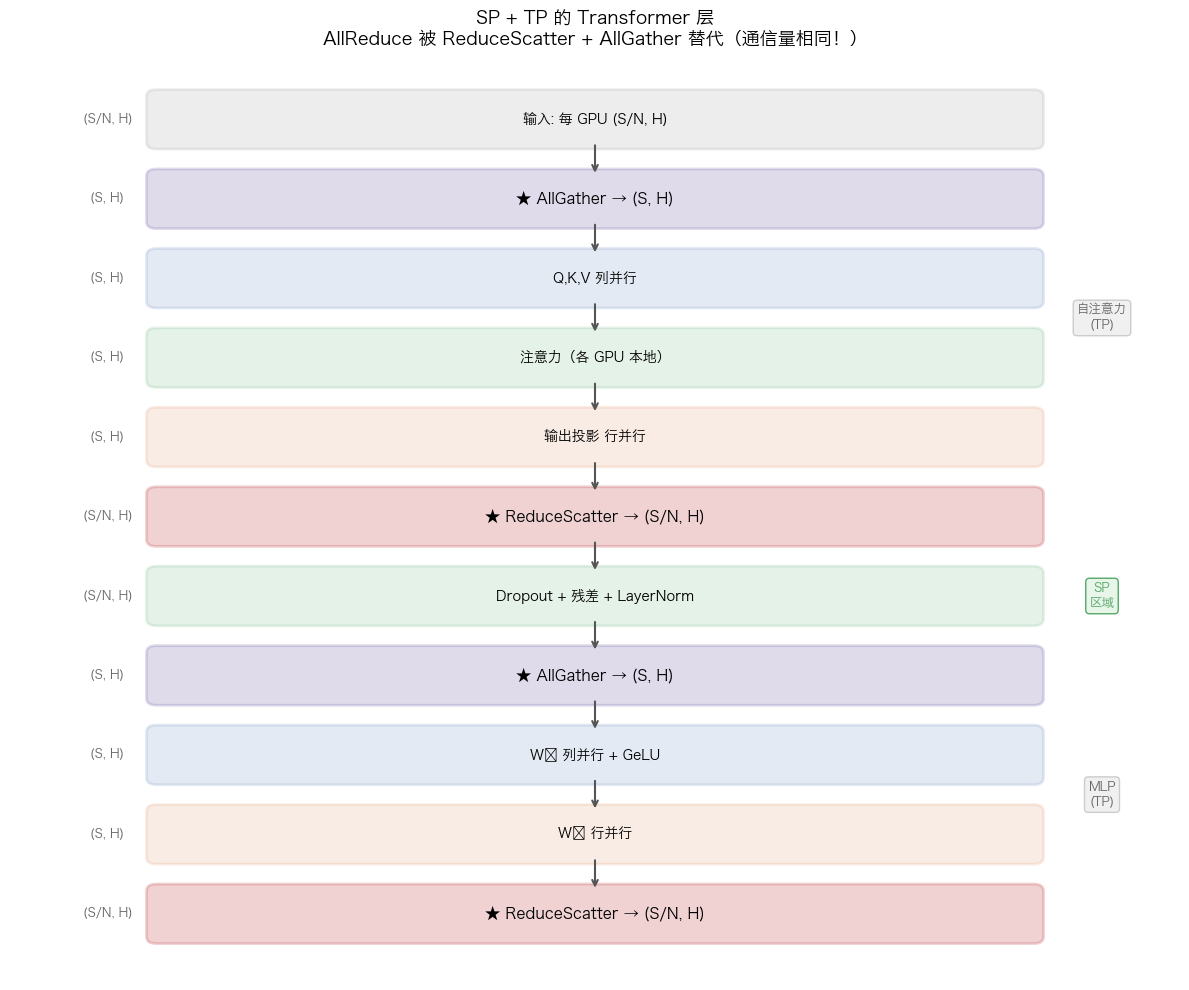

In [10]:
def draw_sp_tp_transformer():
    """可视化 SP+TP 耦合的完整 Transformer 层。"""
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 14)
    ax.axis("off")

    blocks = [
        (6, 13.0, 9, 0.7, "输入: 每 GPU (S/N, H)",            "#888",     "SP"),
        (6, 11.8, 9, 0.7, "★ AllGather → (S, H)",              "#8172B3",  "comm"),
        (6, 10.6, 9, 0.7, "Q,K,V 列并行",                      GPU_COLORS[0], "TP"),
        (6,  9.4, 9, 0.7, "注意力（各 GPU 本地）",              GPU_COLORS[2], "TP"),
        (6,  8.2, 9, 0.7, "输出投影 行并行",                    GPU_COLORS[1], "TP"),
        (6,  7.0, 9, 0.7, "★ ReduceScatter → (S/N, H)",        "#C44E52",  "comm"),
        (6,  5.8, 9, 0.7, "Dropout + 残差 + LayerNorm",         "#55A868",  "SP"),
        (6,  4.6, 9, 0.7, "★ AllGather → (S, H)",               "#8172B3",  "comm"),
        (6,  3.4, 9, 0.7, "W₁ 列并行 + GeLU",                  GPU_COLORS[0], "TP"),
        (6,  2.2, 9, 0.7, "W₂ 行并行",                         GPU_COLORS[1], "TP"),
        (6,  1.0, 9, 0.7, "★ ReduceScatter → (S/N, H)",        "#C44E52",  "comm"),
    ]

    for x, y, w, h, text, color, region in blocks:
        alpha = 0.25 if "★" in text else 0.15
        box = mpatches.FancyBboxPatch(
            (x - w/2, y - h/2), w, h,
            boxstyle="round,pad=0.1", facecolor=color, alpha=alpha,
            edgecolor=color, linewidth=2
        )
        ax.add_patch(box)
        fs = 11 if "★" in text else 10
        ax.text(x, y, text, ha="center", va="center", fontsize=fs, fontweight="bold")

    ax.text(11.2, 10.0, "自注意力\n(TP)", ha="center", va="center",
            fontsize=9, fontstyle="italic", color="#666",
            bbox=dict(boxstyle="round", fc="#f0f0f0", ec="#ccc"))
    ax.text(11.2, 2.8, "MLP\n(TP)", ha="center", va="center",
            fontsize=9, fontstyle="italic", color="#666",
            bbox=dict(boxstyle="round", fc="#f0f0f0", ec="#ccc"))
    ax.text(11.2, 5.8, "SP\n区域", ha="center", va="center",
            fontsize=9, fontstyle="italic", color="#55A868",
            bbox=dict(boxstyle="round", fc="#e8f5e9", ec="#55A868"))

    for i in range(len(blocks) - 1):
        y1 = blocks[i][1] - blocks[i][3]/2
        y2 = blocks[i + 1][1] + blocks[i + 1][3]/2
        ax.annotate("", xy=(6, y2), xytext=(6, y1),
                    arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"))

    shapes = [
        (13.0, "(S/N, H)"), (11.8, "(S, H)"), (10.6, "(S, H)"),
        (9.4, "(S, H)"), (8.2, "(S, H)"), (7.0, "(S/N, H)"),
        (5.8, "(S/N, H)"), (4.6, "(S, H)"), (3.4, "(S, H)"),
        (2.2, "(S, H)"), (1.0, "(S/N, H)")
    ]
    for y, shape in shapes:
        ax.text(1.0, y, shape, ha="center", va="center", fontsize=9,
                color="#666", fontstyle="italic")

    ax.set_title(
        "SP + TP 的 Transformer 层\n"
        "AllReduce 被 ReduceScatter + AllGather 替代（通信量相同！）",
        fontsize=13, fontweight="bold"
    )
    fig.tight_layout()
    return fig

fig = draw_sp_tp_transformer()
plt.show()

In [11]:
# 端到端模拟: SP+TP MLP 块
# 2 GPU, seq=6, hidden=4, intermediate=6
torch.manual_seed(7)
num_gpus = 2
seq_len, hidden_dim, inter_dim = 6, 4, 6

X = (torch.randn(seq_len, hidden_dim) * 2).round() / 2
W1 = (torch.randn(hidden_dim, inter_dim) * 2).round() / 2
W2 = (torch.randn(inter_dim, hidden_dim) * 2).round() / 2
ln = nn.LayerNorm(hidden_dim)

# --- 参考: 单 GPU ---
Y_ref = F.gelu(ln(X) @ W1) @ W2

# --- SP+TP 模拟 ---
# 第1步: 输入按序列分区（SP 区域）
X_sp = X.chunk(num_gpus, dim=0)  # 每 GPU (S/N, H)
print("第1步 — SP 输入:   每 GPU", X_sp[0].shape)

# 第2步: 对各分块做 LayerNorm（SP — 无需通信）
X_ln = [ln(chunk) for chunk in X_sp]
print("第2步 — LayerNorm: 每 GPU", X_ln[0].shape, "（无通信）")

# 第3步: AllGather 获取完整序列以进入 TP
X_full = simulate_allgather(X_ln)
print("第3步 — AllGather: 每 GPU", X_full[0].shape)

# 第4步: 列并行 W1 + GeLU
W1_chunks = W1.chunk(num_gpus, dim=1)
H_parts = [F.gelu(X_full[g] @ W1_chunks[g]) for g in range(num_gpus)]
print("第4步 — 列并行:   每 GPU", H_parts[0].shape)

# 第5步: 行并行 W2
W2_chunks = W2.chunk(num_gpus, dim=0)
Y_parts = [H_parts[g] @ W2_chunks[g] for g in range(num_gpus)]
print("第5步 — 行并行:   每 GPU", Y_parts[0].shape, "（部分和）")

# 第6步: ReduceScatter（替代 AllReduce！）
Y_sp = simulate_reduce_scatter(Y_parts)
print("第6步 — ReduceScatter: 每 GPU", Y_sp[0].shape, "← 回到 SP！")

第1步 — SP 输入:   每 GPU torch.Size([3, 4])
第2步 — LayerNorm: 每 GPU torch.Size([3, 4]) （无通信）
第3步 — AllGather: 每 GPU torch.Size([6, 4])
第4步 — 列并行:   每 GPU torch.Size([6, 3])
第5步 — 行并行:   每 GPU torch.Size([6, 4]) （部分和）
第6步 — ReduceScatter: 每 GPU torch.Size([3, 4]) ← 回到 SP！


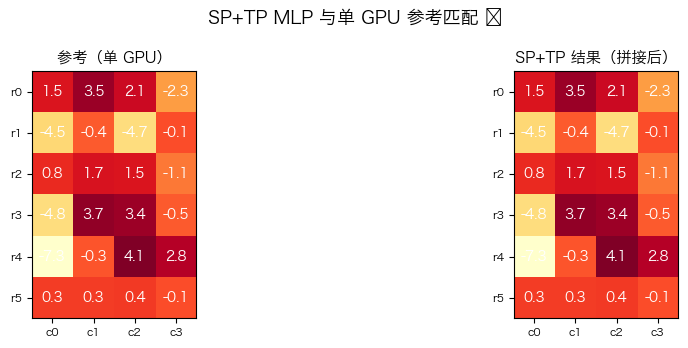

✓ SP+TP 结果匹配！相同的数学，更少的每 GPU 显存。


In [12]:
# 验证：拼接 SP 分块并与参考比较
Y_combined = torch.cat(Y_sp, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
show_matrix(Y_ref,      ax=axes[0], title="参考（单 GPU）")
show_matrix(Y_combined, ax=axes[1], title="SP+TP 结果（拼接后）")
fig.suptitle("SP+TP MLP 与单 GPU 参考匹配 ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_combined, Y_ref, atol=1e-5)
print("✓ SP+TP 结果匹配！相同的数学，更少的每 GPU 显存。")

### 仅 TP vs SP+TP：对比

| | 仅 TP | SP + TP |
|---|---|---|
| **LayerNorm/Dropout** | 各 GPU 完整 `(S, H)` | 各 GPU 拆分 `(S/N, H)` |
| **注意力/MLP** | 被 TP 拆分 | 同——被 TP 拆分 |
| **通信** | 每层 2 次 AllReduce | 2 次 AllGather + 2 次 ReduceScatter |
| **通信量** | 2 × 2SH = **4SH** | 2 × SH + 2 × SH = **4SH** |
| **激活显存** | 大部分保持完整 `(S, H)` | SP 区域为 `(S/N, H)` |

**相同的通信量，更少的显存！**

---
## 5. 显存节省：前后对比

量化 SP 带来的激活显存节省。我们以 GPT-3 规模的模型为例。

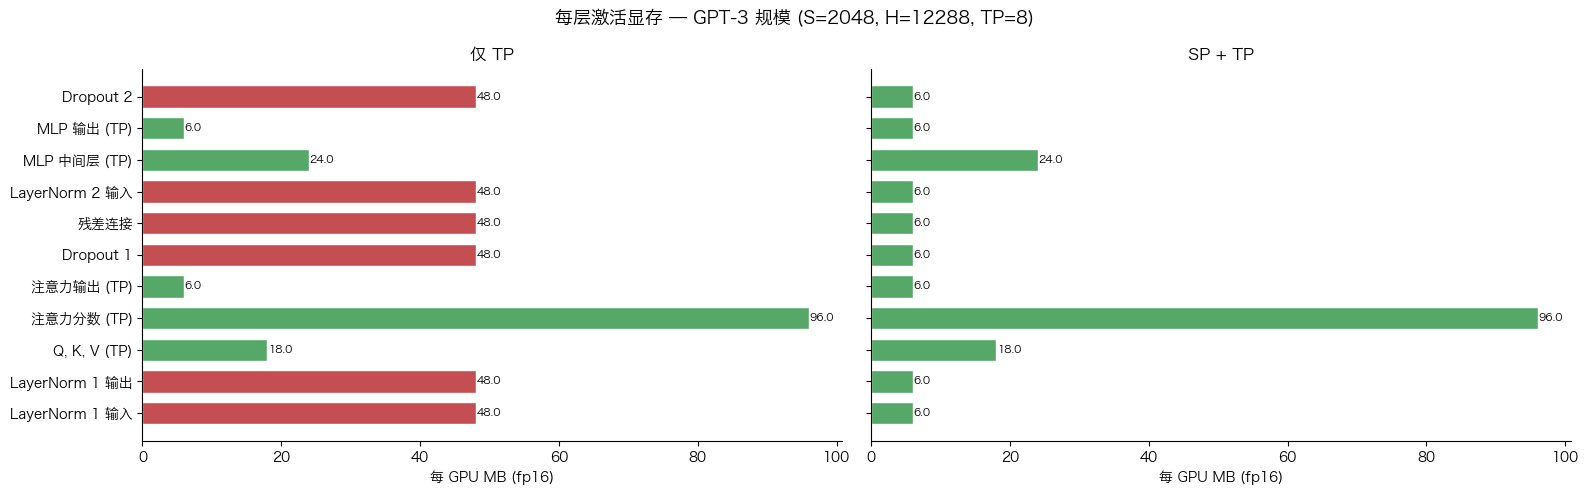

仅 TP:  438.0 MB / GPU / 层
SP+TP:  186.0 MB / GPU / 层
节省:   58% 激活显存减少！


In [13]:
def compute_activation_memory(seq_len, hidden, num_heads, tp_degree, use_sp=False):
    """计算单层 Transformer 每 GPU 激活显存（字节, fp16）。

    各组件及其激活形状:
    - LayerNorm 输入: (S, H) — SP 时为 (S/N, H)
    - Q,K,V 投影: 已被 TP 拆分 → (S, H/N)
    - 注意力分数: (num_heads/N, S, S) — 按头拆分
    - 注意力输出: (S, H/N)
    - MLP 中间层: (S, 4H/N) — 列并行
    - Dropout mask: 与输入形状相同
    """
    N = tp_degree
    bpe = 2  # 每元素字节数 (fp16)
    S = seq_len
    H = hidden

    # SP 区域: 完整或拆分
    sp_seq = S // N if use_sp else S

    memory = {
        "LayerNorm 1 输入":     sp_seq * H * bpe,
        "LayerNorm 1 输出":     sp_seq * H * bpe,
        "Q, K, V (TP)":         3 * S * (H // N) * bpe,
        "注意力分数 (TP)":       (num_heads // N) * S * S * bpe,
        "注意力输出 (TP)":       S * (H // N) * bpe,
        "Dropout 1":             sp_seq * H * bpe,
        "残差连接":              sp_seq * H * bpe,
        "LayerNorm 2 输入":     sp_seq * H * bpe,
        "MLP 中间层 (TP)":      S * (4 * H // N) * bpe,
        "MLP 输出 (TP)":        S * (H // N) * bpe,
        "Dropout 2":             sp_seq * H * bpe,
    }
    return memory

# GPT-3 175B 参数
seq_len = 2048
hidden = 12288
num_heads = 96
tp_degree = 8

mem_tp_only = compute_activation_memory(seq_len, hidden, num_heads, tp_degree, use_sp=False)
mem_sp_tp = compute_activation_memory(seq_len, hidden, num_heads, tp_degree, use_sp=True)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, mem, title, color_scheme in [
    (axes[0], mem_tp_only, "仅 TP", {"SP": "#C44E52", "TP": "#55A868"}),
    (axes[1], mem_sp_tp,   "SP + TP", {"SP": "#55A868", "TP": "#55A868"}),
]:
    names = list(mem.keys())
    sizes_mb = [v / 1024**2 for v in mem.values()]
    colors = [color_scheme["TP"] if "(TP)" in n else color_scheme["SP"] for n in names]

    bars = ax.barh(names, sizes_mb, color=colors, edgecolor="white", height=0.7)
    for bar, val in zip(bars, sizes_mb):
        if val > 0.5:
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    f"{val:.1f}", va="center", fontsize=8)

    ax.set_xlabel("每 GPU MB (fp16)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(f"每层激活显存 — GPT-3 规模 (S={seq_len}, H={hidden}, TP={tp_degree})",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

total_tp = sum(mem_tp_only.values()) / 1024**2
total_sp = sum(mem_sp_tp.values()) / 1024**2
print(f"仅 TP:  {total_tp:.1f} MB / GPU / 层")
print(f"SP+TP:  {total_sp:.1f} MB / GPU / 层")
print(f"节省:   {(1 - total_sp / total_tp):.0%} 激活显存减少！")

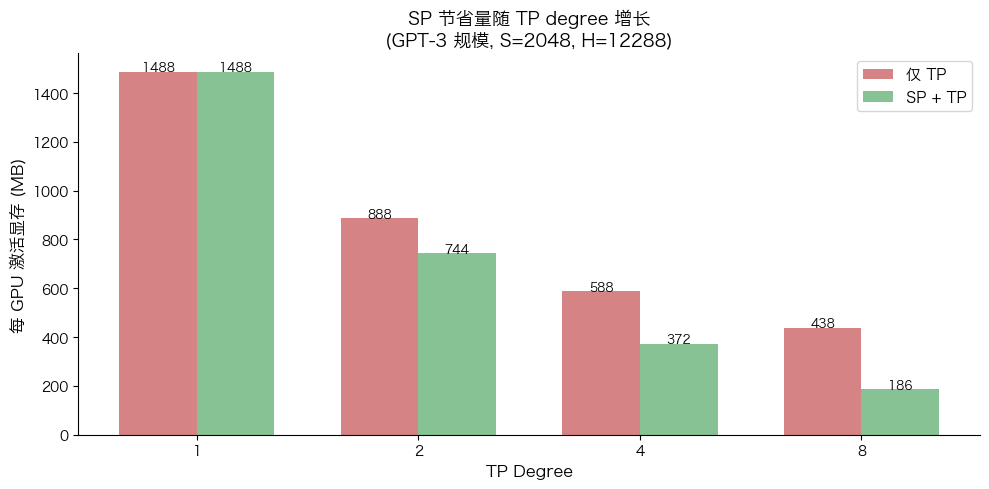

TP=1: 1488 MB → 1488 MB (节省 0%)
TP=2: 888 MB → 744 MB (节省 16%)
TP=4: 588 MB → 372 MB (节省 37%)
TP=8: 438 MB → 186 MB (节省 58%)


In [14]:
# 节省量如何随 TP degree 增长？
tp_degrees = [1, 2, 4, 8]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tp_degrees))
width = 0.35

tp_totals = []
sp_totals = []
for tp in tp_degrees:
    mem_tp = compute_activation_memory(2048, 12288, 96, tp, use_sp=False)
    mem_sp = compute_activation_memory(2048, 12288, 96, tp, use_sp=True)
    tp_totals.append(sum(mem_tp.values()) / 1024**2)
    sp_totals.append(sum(mem_sp.values()) / 1024**2)

bars1 = ax.bar(x - width/2, tp_totals, width, label="仅 TP", color="#C44E52", alpha=0.7)
bars2 = ax.bar(x + width/2, sp_totals, width, label="SP + TP", color="#55A868", alpha=0.7)

for bar, val in zip(bars1, tp_totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}", ha="center", fontsize=9)
for bar, val in zip(bars2, sp_totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val:.0f}", ha="center", fontsize=9)

ax.set_xlabel("TP Degree", fontsize=12)
ax.set_ylabel("每 GPU 激活显存 (MB)", fontsize=12)
ax.set_title("SP 节省量随 TP degree 增长\n(GPT-3 规模, S=2048, H=12288)",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(tp_degrees)
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
plt.show()

for tp, tp_v, sp_v in zip(tp_degrees, tp_totals, sp_totals):
    print(f"TP={tp}: {tp_v:.0f} MB → {sp_v:.0f} MB (节省 {(1 - sp_v/tp_v):.0%})")

---
## 6. 在大语言模型中的应用

SP 在生产系统中**始终与 TP 一起使用**——本质上是"免费"的（通信量相同），却能显著节省激活显存。

| 模型 | TP | SP | 说明 |
|------|----|----|------|
| Megatron-LM v2+ | 8 | 8 | SP 在 Megatron v2 论文中提出 |
| LLaMA 2/3 | 8 | 8 | 采用 Megatron 风格的 SP+TP |
| PaLM | 8 | 8 | TPU 上等效的 SP+TP |
| GPT-NeoX | 8 | 8 | TP 默认启用 SP |

SP 的 degree 与 TP 相同——如果使用 TP=8，SP 也是跨这 8 个 GPU。没有单独的"SP degree"参数。

---
## 7. 需要 GPU：真实多 GPU SP+TP

> **需要 GPU** — 请在多卡 GPU 机器上运行此 cell（推荐 4+ GPU）。

In [15]:
# [需要 GPU]
# 真实多 GPU SP+TP: LayerNorm 用 SP, MLP 用 TP, 以 AllGather/ReduceScatter 衔接
# 在远程机器运行: a multi-GPU machine (4× GPU)

import torch
import torch.distributed as dist
import torch.multiprocessing as mp
import torch.nn as nn
import torch.nn.functional as F
import os

def sp_tp_mlp_worker(rank, world_size, X_shared, W1_shared, W2_shared, ln_weight, ln_bias, results):
    """SP+TP MLP 的单 GPU worker。"""
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "29501"
    dist.init_process_group("nccl", rank=rank, world_size=world_size)

    device = torch.device(f"cuda:{rank}")
    seq_len = X_shared.shape[0]
    chunk_size = seq_len // world_size

    # SP: 每个 GPU 获取其序列分块
    X_local = X_shared[rank * chunk_size:(rank + 1) * chunk_size].to(device)

    # 对本地分块做 LayerNorm（SP 区域 — 无需通信）
    ln = nn.LayerNorm(X_shared.shape[1]).to(device)
    ln.weight.data.copy_(ln_weight.to(device))
    ln.bias.data.copy_(ln_bias.to(device))
    X_normed = ln(X_local)

    # AllGather 获取完整序列以进入 TP
    gathered = [torch.zeros_like(X_normed) for _ in range(world_size)]
    dist.all_gather(gathered, X_normed)
    X_full = torch.cat(gathered, dim=0)

    # 列并行 W1 + GeLU
    inter_size = W1_shared.shape[1]
    chunk_cols = inter_size // world_size
    W1_local = W1_shared[:, rank * chunk_cols:(rank + 1) * chunk_cols].to(device)
    hidden = F.gelu(X_full @ W1_local)

    # 行并行 W2
    W2_local = W2_shared[rank * chunk_cols:(rank + 1) * chunk_cols, :].to(device)
    output = hidden @ W2_local  # 部分和

    # ReduceScatter: 求和部分结果并沿序列维度散射
    output_chunk = torch.zeros(chunk_size, W2_shared.shape[1], device=device)
    dist.reduce_scatter_tensor(output_chunk, output)

    results[rank] = output_chunk.cpu()
    dist.destroy_process_group()

if torch.cuda.is_available() and torch.cuda.device_count() >= 4:
    world_size = 4
    seq_len, hidden_dim, inter_dim = 32, 64, 256

    torch.manual_seed(42)
    X = torch.randn(seq_len, hidden_dim)
    W1 = torch.randn(hidden_dim, inter_dim)
    W2 = torch.randn(inter_dim, hidden_dim)
    ln = nn.LayerNorm(hidden_dim)

    # 参考
    Y_ref = F.gelu(ln(X) @ W1) @ W2

    manager = mp.Manager()
    results = manager.dict()
    mp.spawn(sp_tp_mlp_worker,
             args=(world_size, X, W1, W2, ln.weight.data, ln.bias.data, results),
             nprocs=world_size)

    Y_sp_tp = torch.cat([results[r] for r in range(world_size)], dim=0)
    print(f"最大误差: {(Y_sp_tp - Y_ref).abs().max().item():.2e}")
    print("✓ 真实多 GPU SP+TP 与参考匹配！")
else:
    print("跳过: 需要 4 个 CUDA GPU。连接方式: a multi-GPU machine")

跳过: 需要 4 个 CUDA GPU。连接方式: a multi-GPU machine


> **进阶内容——可以跳过。** 本节引用了 Megatron-LM 的内部实现细节。仅为完整性而保留，理解上面的 SP 核心概念并不需要本节内容。

---
## 8. Megatron-LM 参考实现

Megatron-LM 通过替换 TP 的通信原语来实现 SP。关键改动在 `mappings.py` 中的自定义 autograd 函数：

In [16]:
code_reference(
    code="""
# 当 sequence_parallel=True 时，TP 的通信方式改变：
#
# 仅 TP:
#   列并行输入:  前向 Identity, 反向 AllReduce
#   行并行输出:  前向 AllReduce, 反向 Identity
#
# SP + TP:
#   列并行输入:  前向 AllGather, 反向 ReduceScatter
#   行并行输出:  前向 ReduceScatter, 反向 AllGather

class _AllGatherFromSequenceParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_):
        # 沿序列维度 AllGather: (S/N, H) → (S, H)
        return _gather_along_first_dim(input_)

    @staticmethod
    def backward(ctx, grad_output):
        # 反向时 ReduceScatter: (S, H) → (S/N, H)
        return _reduce_scatter_along_first_dim(grad_output)

class _ReduceScatterToSequenceParallelRegion(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_):
        # 沿序列维度 ReduceScatter: (S, H) → (S/N, H)
        return _reduce_scatter_along_first_dim(input_)

    @staticmethod
    def backward(ctx, grad_output):
        # 反向时 AllGather: (S/N, H) → (S, H)
        return _gather_along_first_dim(grad_output)
""",
    source="Megatron-LM",
    filepath="megatron/core/tensor_parallel/mappings.py"
)

注意 autograd 中的**共轭模式 (conjugate pattern)**：
- 前向 AllGather ↔ 反向 ReduceScatter
- 前向 ReduceScatter ↔ 反向 AllGather

这确保了梯度在 SP+TP 边界处的正确传播。

| 前向 | 反向 | 使用位置 |
|------|------|----------|
| AllGather | ReduceScatter | 列并行之前（SP → TP） |
| ReduceScatter | AllGather | 行并行之后（TP → SP） |

Megatron-LM 关键文件：
- `megatron/core/tensor_parallel/mappings.py` — SP 通信原语
- `megatron/core/tensor_parallel/layers.py` — `ColumnParallelLinear`、`RowParallelLinear`，带 `sequence_parallel` 标志
- `megatron/core/transformer/transformer_layer.py` — 完整 Transformer 层中 SP 与 TP 的连接

---
## 总结与延伸阅读

### 要点回顾

1. 仅用 TP 时，LayerNorm/Dropout 保留**完整重复激活**——浪费显存
2. **ReduceScatter** = 归约（求和）+ 散射（拆分）——AllGather 的逆操作
3. **AllReduce ≡ ReduceScatter + AllGather** —— 通信量相同
4. SP 对非 TP 操作（LayerNorm、Dropout、残差）沿**序列维度**拆分
5. SP 用 ReduceScatter + AllGather 替代 AllReduce —— **通信量相同，显存更少**
6. SP 始终与 TP 以**相同 degree** 耦合（通常为 8）
7. 在 Megatron-LM 中，SP 只是 TP 层上的一个标志——改动极小

### 延伸阅读

- [Reducing Activation Recomputation in Large Transformer Models](https://arxiv.org/abs/2205.05198) — Megatron SP 论文
- [Megatron-LM: Training Multi-Billion Parameter Language Models Using Model Parallelism](https://arxiv.org/abs/1909.08053)
- [NVIDIA Megatron-Core](https://github.com/NVIDIA/Megatron-LM) — 见 `megatron/core/tensor_parallel/`
- 上一篇: [02-tensor-parallelism/](02-tensor-parallelism.ipynb) — TP 基础
- 下一篇: [05-context-parallelism/](05-context-parallelism.ipynb) — 长序列的注意力拆分